In [2]:
import pandas as pd
import shap
import joblib
import matplotlib.pyplot as plt

C:\Users\Zina\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Trained Model

The optimized XGBoost model obtained after hyperparameter tuning is loaded from the models folder.

This allows us to explain predictions without retraining the model.

In [8]:
model = joblib.load("../models/xgboost_final_model.pkl")

## Load Processed Dataset

The feature-engineered dataset created in the previous step is loaded.

The dataset contains only machine-learning-ready variables.

In [13]:
df = pd.read_csv(
    "../data/processed/hr_feature_engineered.csv"
)

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,2,0,...,3,1,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,3,1,...,4,4,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,4,1,...,3,2,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,4,0,...,3,3,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,1,...,3,4,1,6,3,3,2,2,2,2


## Prepare Features

The target variable (Attrition) is separated from the predictor variables.

The features will be used as input for SHAP explanations.

In [18]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

## Create SHAP Explainer

SHAP (SHapley Additive exPlanations) is used to interpret the predictions of the XGBoost model.

The explainer calculates how much each feature contributes to increasing or decreasing employee attrition risk.

In [22]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X)

print("SHAP values calculated successfully")

SHAP values calculated successfully


## Global Feature Importance

This section identifies the most important features influencing employee attrition predictions across the entire dataset.

Features with higher SHAP values have a stronger impact on the model output.

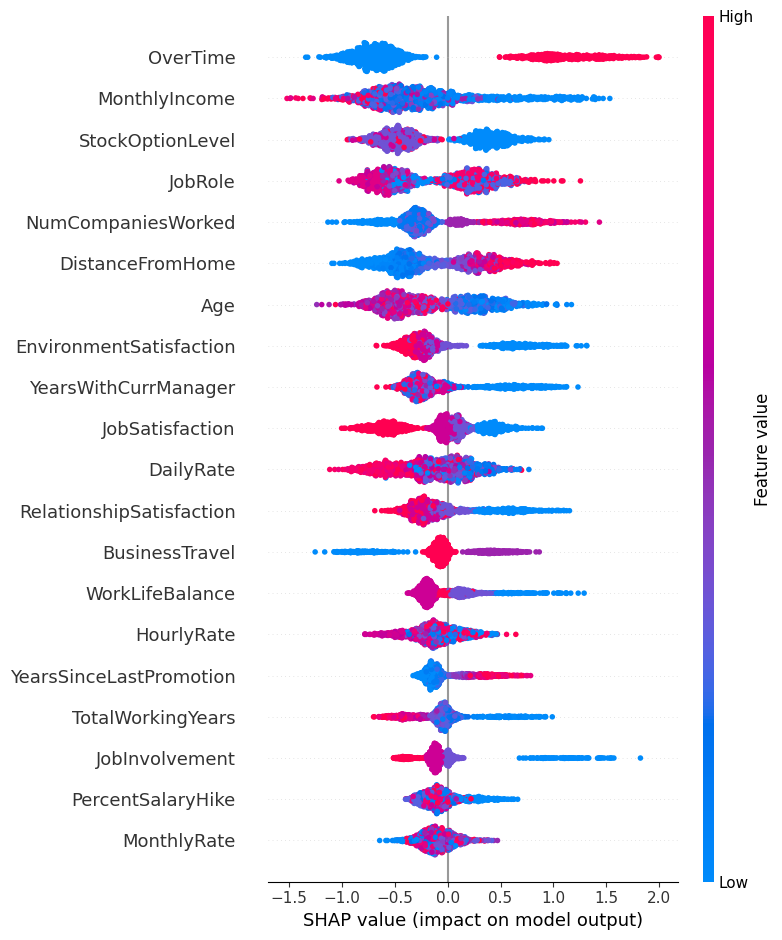

In [23]:
shap.summary_plot(
    shap_values,
    X
)

## Interpretation of SHAP Feature Importance

The SHAP analysis identifies the main drivers influencing employee attrition predictions.

The most influential features are OverTime, MonthlyIncome, StockOptionLevel, and JobRole.

These insights improve model transparency by showing HR managers which workforce factors contribute most to attrition risk.